<a href="https://colab.research.google.com/github/sifat-lab/ML-powered_renewabl_-energy/blob/main/ml/spikesoil_ml_02_deepsolareye.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA = '/content/drive/MyDrive/DeepSolarEye pipeline/'

Mounted at /content/drive


45754 images
               loss           irr
count  45721.000000  45721.000000
mean       0.265289      0.345824
std        0.284070      0.206185
min        0.000000      0.002682
25%        0.031849      0.189627
50%        0.119965      0.310827
75%        0.522654      0.483886
max        0.996159      1.006125


Text(0.5, 1.0, 'Power-loss label distribution')

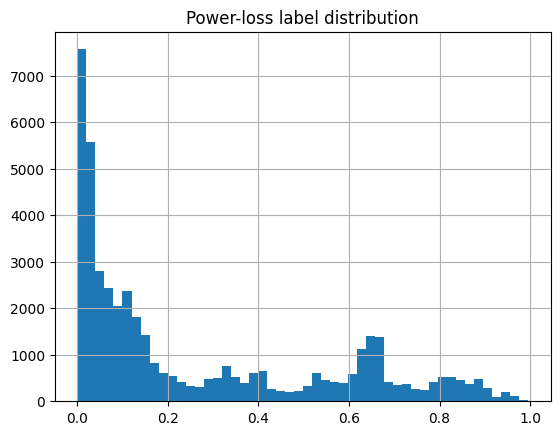

In [4]:
import zipfile, re, pandas as pd
import matplotlib.pyplot as plt

zpath = DATA + 'SolarPanelSoilingImageDataset.zip'   # Drive-এ তুলে নাও আগে
names = [n for n in zipfile.ZipFile(zpath).namelist() if n.endswith('.jpg')]
print(len(names), "images")

rows = []
# Modified regex to prevent capturing the dot from the .jpg file extension
pat = re.compile(r'L_([\d.]+)_I_([\d.]+)\.jpg$')
for n in names:
    m = pat.search(n)
    if m:
        rows.append({'file': n, 'loss': float(m.group(1)), 'irr': float(m.group(2))})
labels = pd.DataFrame(rows)
print(labels.describe())
labels['loss'].hist(bins=50); plt.title('Power-loss label distribution')

            timestamp      loss       irr
0 2017-06-26 13:23:42  0.020533  0.372043
1 2017-06-16 11:39:44  0.555993  0.308969
2 2017-06-27 07:39:05  0.153320  0.162675
3 2017-06-22 17:39:32  0.729038  0.093682
4 2017-06-15 10:22:02  0.114351  0.441263


Text(0.5, 1.0, 'Loss vs irradiance — DeepSolarEye')

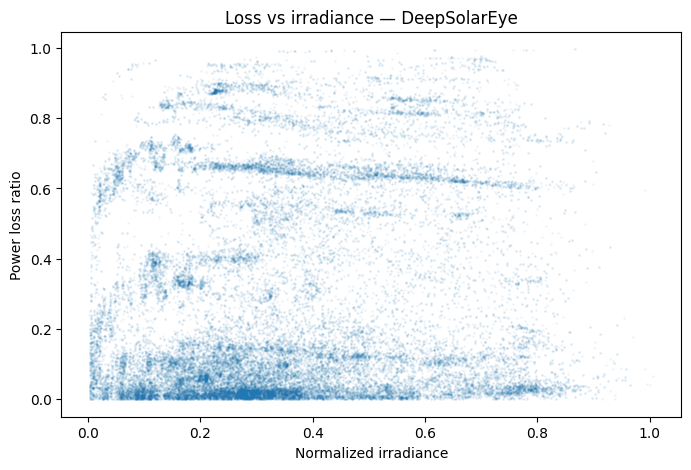

In [6]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Updated regex to match the double underscores in time components: hh__mm__ss
pat_t = re.compile(r'solar_\w+_(\w+)_(\d+)_(\d+)__(\d+)__(\d+)_(\d{4})')
MONTHS = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
          'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}

def parse_time(name):
    m = pat_t.search(name)
    if not m: return None
    mon, day, hh, mm, ss, yr = m.groups()
    try:
        return pd.Timestamp(int(yr), MONTHS[mon], int(day), int(hh), int(mm), int(ss))
    except:
        return None

labels['timestamp'] = labels['file'].apply(parse_time)
# Ensure the column is datetime type and drop rows where parsing failed
labels['timestamp'] = pd.to_datetime(labels['timestamp'], errors='coerce')
labels = labels.dropna(subset=['timestamp'])

labels['hour'] = labels['timestamp'].dt.hour + labels['timestamp'].dt.minute/60
print(labels[['timestamp','loss','irr']].head())

# Bonus check: loss vs irradiance scatter — সম্পর্ক আছে কিনা চোখে দেখো
plt.figure(figsize=(8,5))
plt.scatter(labels['irr'], labels['loss'], s=1, alpha=0.05)
plt.xlabel('Normalized irradiance'); plt.ylabel('Power loss ratio')
plt.title('Loss vs irradiance — DeepSolarEye')

In [7]:
labels.to_csv(DATA + 'deepsolareye_labels.csv', index=False)